In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv('ispu_dki_all.csv')
df.head()

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


In [3]:
df.shape

(5538, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   object 
 1   stasiun   5537 non-null   object 
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   object 
 10  categori  5538 non-null   object 
dtypes: float64(7), object(4)
memory usage: 476.1+ KB


In [5]:
df.describe()

,pm25,pm10,so2,co,o3,no2,max
count,1516.000000,5223.000000,5408.000000,5450.000000,5434.000000,5432.000000,5537.000000
mean,89.742084,56.407046,22.436206,20.422752,77.465771,14.349227,97.625790
std,26.615960,20.010963,15.450584,11.966246,51.798101,10.051099,40.955382
min,10.000000,2.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,71.000000,45.000000,10.000000,12.000000,36.000000,8.000000,70.000000
50%,90.000000,57.000000,18.000000,18.000000,69.000000,12.000000,90.000000
75%,107.000000,67.000000,32.000000,26.000000,103.000000,18.000000,114.000000
max,287.000000,187.000000,112.000000,119.000000,314.000000,202.000000,314.000000


# Feature Engineering

Renaming the columns from Bahasa Indonesia to English

In [6]:
# Rename the columns
df.rename(columns={'tanggal': 'date', 'stasiun': 'station', 'categori': 'category'}, inplace=True)
df.head()

,date,station,pm25,pm10,so2,co,o3,no2,max,critical,category
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


In [7]:
# category is the target, check category's unique values
uniqueVal = df['category'].unique()
print(uniqueVal)

['SEDANG' 'BAIK' 'TIDAK SEHAT' 'TIDAK ADA DATA' 'SANGAT TIDAK SEHAT'
 'BERBAHAYA']


In [8]:
# rename the values to English and delete NO DATA (TIDAK ADA DATA) rows
df['category'] = df['category'].replace({'SEDANG':'MODERATE', 'BAIK': 'GOOD', 'TIDAK SEHAT': 'UNHEALTHY', 'TIDAK ADA DATA': 'NO DATA', 'SANGAT TIDAK SEHAT': 'VERY UNHEALTHY', 'BERBAHAYA': 'DANGER'})
df = df[df['category'] != 'NO DATA']
df['category'].value_counts()

category
MODERATE          3187
UNHEALTHY         1827
GOOD               316
VERY UNHEALTHY     203
DANGER               1
Name: count, dtype: int64

In 'category' column, DANGER only has 1 value which is really low. Therefore, it's modified to VERY UNHEALTHY value.

In [9]:
df['category'] = df['category'].replace('DANGER', 'VERY UNHEALTHY')
df['category'].value_counts()

category
MODERATE          3187
UNHEALTHY         1827
GOOD               316
VERY UNHEALTHY     204
Name: count, dtype: int64

Check missing values and duplicated rows

In [10]:
df.isna().sum()

date           0
station        1
pm25        4018
pm10         311
so2          126
co            84
o3           100
no2          102
max            0
critical       0
category       0
dtype: int64

In [11]:
missing_percentages= df.isnull().mean().mul(100).round(2).sort_values(ascending=False)
print(missing_percentages)

pm25        72.61
pm10         5.62
so2          2.28
no2          1.84
o3           1.81
co           1.52
station      0.02
date         0.00
max          0.00
critical     0.00
category     0.00
dtype: float64


In [12]:
df.duplicated().sum()

np.int64(0)

1. there aren't any duplicated rows.
2. column pm25 has to many missing values, eventhough it might be very a critical feature, it's better to drop the column.
3. fill in missing values with > 1% missing data with median, because pollution data usually has spikes.
4. remove missing values with < 1% missing data

In [13]:
# drop column pm25 and other unnecessary columns
df = df.drop(columns=['pm25', 'max', 'critical'])

In [14]:
cols = ['pm10','so2','no2','o3','co']

# fill in median based on station
for c in cols:
    df[c] = df.groupby('station')[c].transform(lambda x: x.fillna(x.median()))
    df[c] = df[c].fillna(df[c].median()) 

In [15]:
df = df.dropna() # delete the rest of the missing values

In [16]:
df.isna().sum()

date        0
station     0
pm10        0
so2         0
co          0
o3          0
no2         0
category    0
dtype: int64

Drop unnecessary columns

In [17]:
df = df.drop(columns=['date', 'station'], axis=1)
df.head()

,pm10,so2,co,o3,no2,category
0,60.0,4.0,73.0,27.0,14.0,MODERATE
1,32.0,2.0,16.0,33.0,9.0,GOOD
2,27.0,2.0,19.0,20.0,9.0,GOOD
3,22.0,2.0,16.0,15.0,6.0,GOOD
4,25.0,2.0,17.0,15.0,8.0,GOOD


# EDA

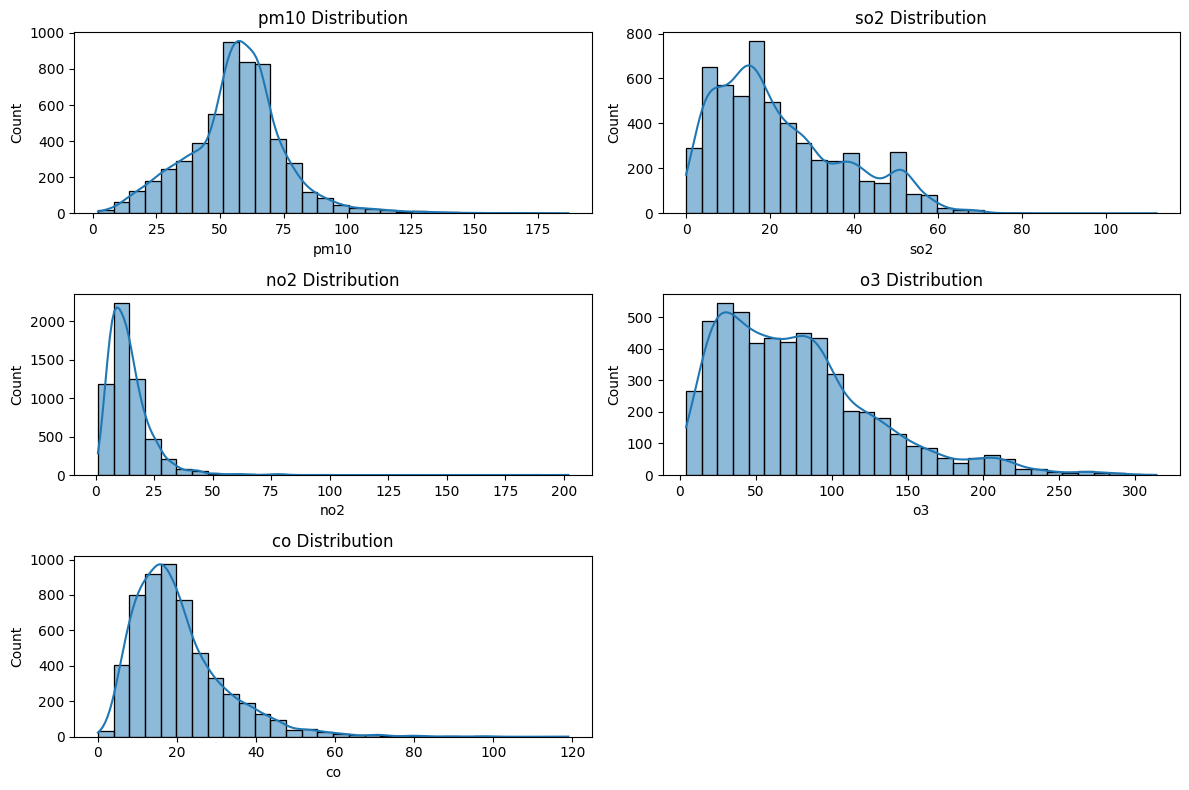

In [18]:
# data distribution
plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

Eventhough the distributions look skewed (right skewed), it's better to not drop the outliers, because high pollution spikes aren't noise, but events.

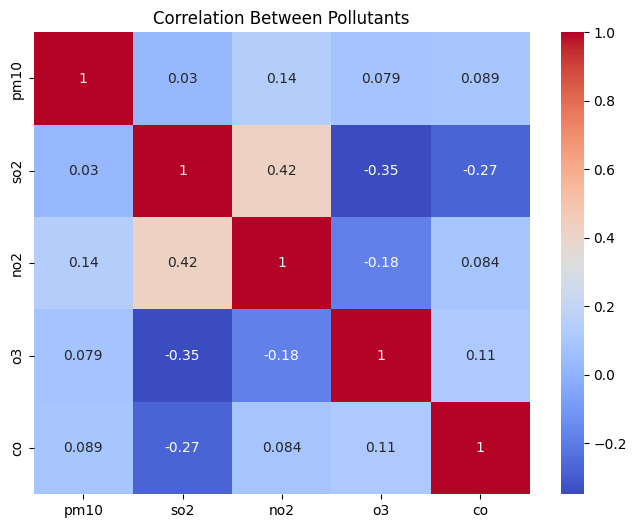

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Pollutants")
plt.show()

In [20]:
df[cols].describe()

,pm10,so2,no2,o3,co
count,5533.000000,5533.000000,5533.000000,5533.000000,5533.000000
mean,56.673595,22.358757,14.292789,76.957166,20.382252
std,19.513824,15.302132,9.968131,51.526238,11.882899
min,2.000000,0.000000,1.000000,4.000000,0.000000
25%,46.000000,11.000000,8.000000,36.000000,12.000000
50%,57.000000,18.000000,12.000000,68.000000,18.000000
75%,66.000000,31.000000,18.000000,102.000000,25.000000
max,187.000000,112.000000,202.000000,314.000000,119.000000


In [21]:
print(df['category'].value_counts())
print()
print(f"Category Distribution Percantage")
print("-"*10)
print(df['category'].value_counts(normalize=True) * 100)

category
MODERATE          3186
UNHEALTHY         1827
GOOD               316
VERY UNHEALTHY     204
Name: count, dtype: int64

Category Distribution Percantage
----------
category
MODERATE          57.581782
UNHEALTHY         33.020061
GOOD               5.711187
VERY UNHEALTHY     3.686969
Name: proportion, dtype: float64


In [22]:
df.isna().sum()

pm10        0
so2         0
co          0
o3          0
no2         0
category    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(2)

In [24]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# Modelling

In [25]:
X = df.drop(columns=['category']) # feature
y = df['category'] # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Changing the target's categorical data to numerical

In [26]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

0: GOOD

1: MODERATE

2: UNHEALTHY

3: VERY UNHEALTHY


### Before SMOTEENN

In [27]:
print('Class distribution before SMOTE:')
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls}: {cnt}')

Class distribution before SMOTE:
  GOOD: 253
  MODERATE: 2547
  UNHEALTHY: 1461
  VERY UNHEALTHY: 163


In [28]:
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [29]:
xgb_preds = xgb_model.predict(X_test)

In [30]:
accuracy_xg = accuracy_score(y_test, xgb_preds)
report_xg = classification_report(y_test, xgb_preds, digits=4)
conf_matrix_xg = confusion_matrix(y_test, xgb_preds)

print("XGBoost")
print(f"Accuracy: {accuracy_xg}")
print("Classification Report:")
print(report_xg)

XGBoost
Accuracy: 0.94579945799458
Classification Report:
              precision    recall  f1-score   support

           0     0.9483    0.8730    0.9091        63
           1     0.9459    0.9608    0.9533       637
           2     0.9391    0.9262    0.9326       366
           3     1.0000    1.0000    1.0000        41

    accuracy                         0.9458      1107
   macro avg     0.9583    0.9400    0.9487      1107
weighted avg     0.9458    0.9458    0.9457      1107



Text(0.5, 25.722222222222214, 'Predicted')

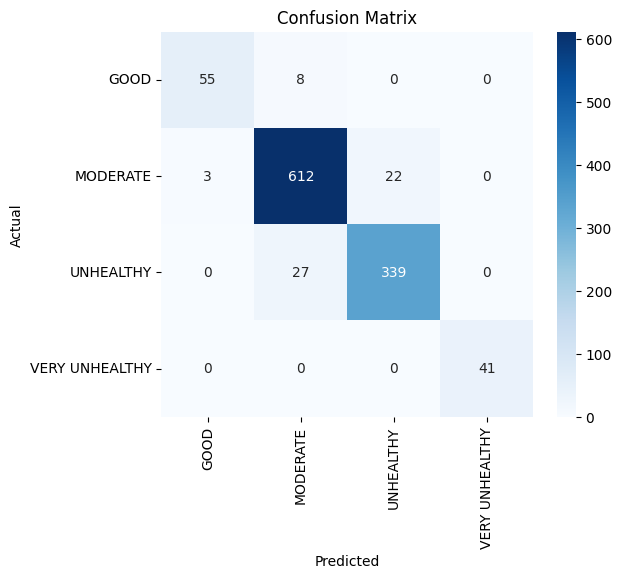

In [31]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_xg, annot=True, fmt='d', cmap='Blues', xticklabels=['GOOD', 'MODERATE', 'UNHEALTHY', 'VERY UNHEALTHY'], yticklabels=['GOOD', 'MODERATE', 'UNHEALTHY', 'VERY UNHEALTHY'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [32]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
rf_preds = rf_model.predict(X_test)

In [34]:
accuracy_rf = accuracy_score(y_test, rf_preds)
report_rf = classification_report(y_test, rf_preds, digits=4)
conf_matrix_rf = confusion_matrix(y_test, rf_preds)

print("Random Forest")
print(f"Accuracy: {accuracy_rf}")
print("Classification Report:")
print(report_rf)

Random Forest
Accuracy: 0.948509485094851
Classification Report:
              precision    recall  f1-score   support

           0     0.9464    0.8413    0.8908        63
           1     0.9394    0.9733    0.9561       637
           2     0.9600    0.9180    0.9385       366
           3     1.0000    1.0000    1.0000        41

    accuracy                         0.9485      1107
   macro avg     0.9615    0.9332    0.9463      1107
weighted avg     0.9489    0.9485    0.9482      1107



Text(0.5, 25.722222222222214, 'Predicted')

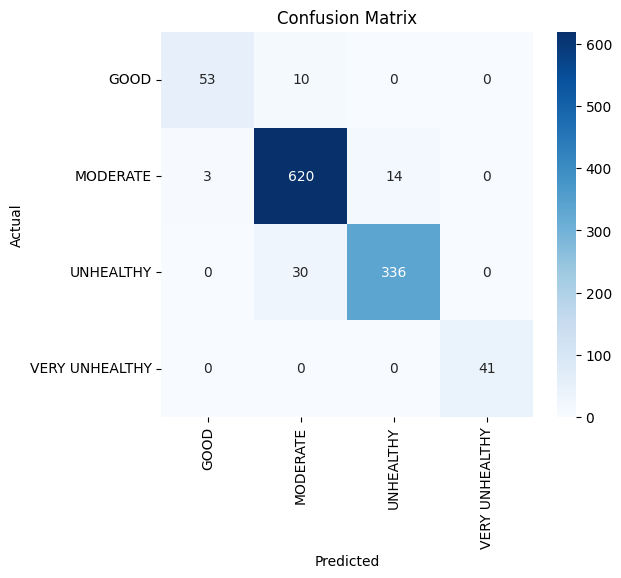

In [35]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['GOOD', 'MODERATE', 'UNHEALTHY', 'VERY UNHEALTHY'], yticklabels=['GOOD', 'MODERATE', 'UNHEALTHY', 'VERY UNHEALTHY'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [36]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
dt_pred = dt_model.predict(X_test)

In [38]:
accuracy_dt = accuracy_score(y_test, dt_pred)
report_dt = classification_report(y_test, dt_pred, digits=4)
conf_matrix_dt = confusion_matrix(y_test, dt_pred)

print("Decision Tree")
print(f"Accuracy: {accuracy_dt}")
print("Classification Report:")
print(report_dt)

Decision Tree
Accuracy: 0.9177958446251129
Classification Report:
              precision    recall  f1-score   support

           0     0.8929    0.7937    0.8403        63
           1     0.9296    0.9325    0.9310       637
           2     0.8970    0.9044    0.9007       366
           3     0.9535    1.0000    0.9762        41

    accuracy                         0.9178      1107
   macro avg     0.9182    0.9076    0.9121      1107
weighted avg     0.9176    0.9178    0.9175      1107



Text(0.5, 25.722222222222214, 'Predicted')

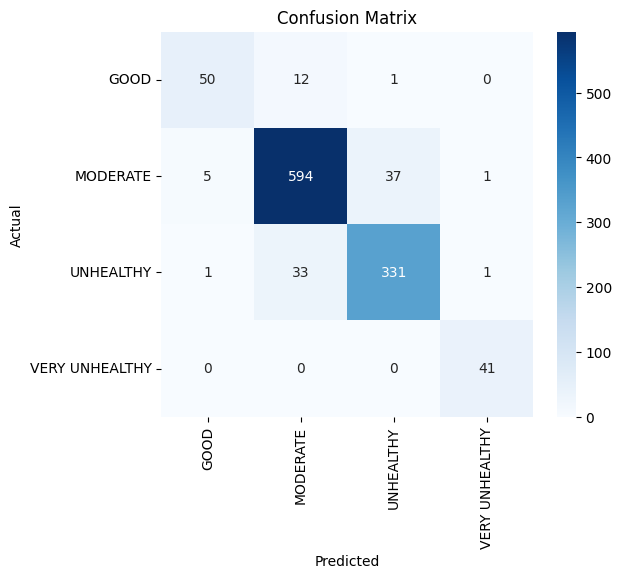

In [39]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['GOOD', 'MODERATE', 'UNHEALTHY', 'VERY UNHEALTHY'], yticklabels=['GOOD', 'MODERATE', 'UNHEALTHY', 'VERY UNHEALTHY'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

### After SMOTEENN and Hyperparameter Tuning

In [40]:
smote_enn = SMOTEENN(random_state=42)
X_train, y_train = smote_enn.fit_resample(X_train, y_train)

print('Distribution After SMOTEEN')
print(pd.Series(y_train).value_counts())

Distribution After SMOTEEN
0    2520
3    2508
2    2266
1    1960
Name: count, dtype: int64


In [ ]:
model_xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

In [42]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5]
}

In [43]:
random_search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_dist,
    n_iter=30,              
    scoring='f1_weighted', 
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,30
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [44]:
print(random_search.best_params_)
model_xgb = random_search.best_estimator_

{'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 1.0}


In [45]:
pred_xgb = model_xgb.predict(X_test)

In [46]:
accuracy_xgb = accuracy_score(y_test, pred_xgb)
report_xgb = classification_report(y_test, pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, pred_xgb)

print("XGBoost")
print(f"Accuracy: {accuracy_xgb}")
print("Classification Report:")
print(report_xgb)

XGBoost
Accuracy: 0.9159891598915989
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.92      0.79        63
           1       0.96      0.90      0.93       637
           2       0.90      0.93      0.92       366
           3       0.89      1.00      0.94        41

    accuracy                           0.92      1107
   macro avg       0.86      0.94      0.89      1107
weighted avg       0.92      0.92      0.92      1107



In [47]:
model_rf = RandomForestClassifier(random_state=42)

In [48]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

In [49]:
random_search = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1_weighted', 
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,30
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [50]:
print(random_search.best_params_)
model_rf = random_search.best_estimator_

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}


In [51]:
pred_rf = model_rf.predict(X_test)

In [52]:
accuracy_rf = accuracy_score(y_test, pred_rf)
report_rf = classification_report(y_test, pred_rf)
conf_matrix_rf = confusion_matrix(y_test, pred_rf)

print("Random Forest")
print(f"Accuracy: {accuracy_rf}")
print("Classification Report:")
print(report_rf)

Random Forest
Accuracy: 0.9322493224932249
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.94      0.85        63
           1       0.96      0.92      0.94       637
           2       0.92      0.94      0.93       366
           3       0.95      1.00      0.98        41

    accuracy                           0.93      1107
   macro avg       0.90      0.95      0.92      1107
weighted avg       0.93      0.93      0.93      1107



In [53]:
model_dt = DecisionTreeClassifier(random_state=42)

In [54]:
param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'splitter': ['best', 'random']
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=model_dt,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,30
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [56]:
print(random_search.best_params_)
model_dt = random_search.best_estimator_

{'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 30, 'criterion': 'entropy'}


In [57]:
pred_dt = model_dt.predict(X_test)

In [58]:
accuracy_dt = accuracy_score(y_test, pred_dt)
report_dt = classification_report(y_test, pred_dt)
conf_matrix_dt = confusion_matrix(y_test, pred_dt)

print("Decision Tree")
print(f"Accuracy: {accuracy_dt}")
print("Classification Report:")
print(report_dt)

Decision Tree
Accuracy: 0.9232158988256549
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.87      0.79        63
           1       0.95      0.92      0.93       637
           2       0.92      0.93      0.93       366
           3       0.93      1.00      0.96        41

    accuracy                           0.92      1107
   macro avg       0.88      0.93      0.90      1107
weighted avg       0.93      0.92      0.92      1107

